<!-- HTML file automatically generated from DocOnce source (https://github.com/doconce/doconce/)
doconce format html hw5.do.txt --no_mako -->
<!-- dom:TITLE: PHY321: Classical Mechanics 1 -->

# Homework 5 (Due 13 Mar)

#### Names of Collaborators - Abhishek Vilekar, Matrim Cirullo-Nesbitt, Andrew Gabaldon

## Exercise 4 (20 pt), Phase Diagrams

One of the most useful tools we can learn from classical mechanics is the phase diagram. For us, it is the plot of the position and velocity of a particle in a 1D system, but the concept can be extended to higher dimensions and to other systems. The phase diagram can tell us about the stability of fixed points, the period of oscillations, and the qualitative behavior of the system. 

In this exercise, we will consider a particle in a potential $U(x)$ and we will plot the phase diagrams using both `quiver` and `streamplot` in `matplotlib`. The purpose of this exercise is to learn how to plot phase diagrams and to interpret the results.

We start with a little code for plotting the phase diagram of the simple harmonic oscillator. The code is written in a way that you can easily modify it to plot the phase diagram of other systems. The key point is to make sure that the `quiver` or `streamplot` function is called with the correct arguments. 


In [1]:
import numpy as np
from math import *
import matplotlib.pyplot as plt
import pandas as pd
%matplotlib inline
plt.style.use('seaborn-v0_8-colorblind')

In [13]:
def SHO(X,V):
    
    # For a simple harmonic oscillator, x' = v, and v' = -x.
    dX = V
    dV = -X
    
    return dX, dV

def generate_phase_space(x_lim, v_lim, grid_size):

    x = np.linspace(x_lim[0], x_lim[1], grid_size)
    v = np.linspace(v_lim[0], v_lim[1], grid_size)
    
    X, V = np.meshgrid(x, v)
    
    dX, dV = SHO(X, V)
    
    return X, V, dX, dV

# Generate phase space
x_lim = (-5, 5)
v_lim = (-5, 5)
grid_size = 20
X, V, dX, dV = generate_phase_space(x_lim, v_lim, grid_size)

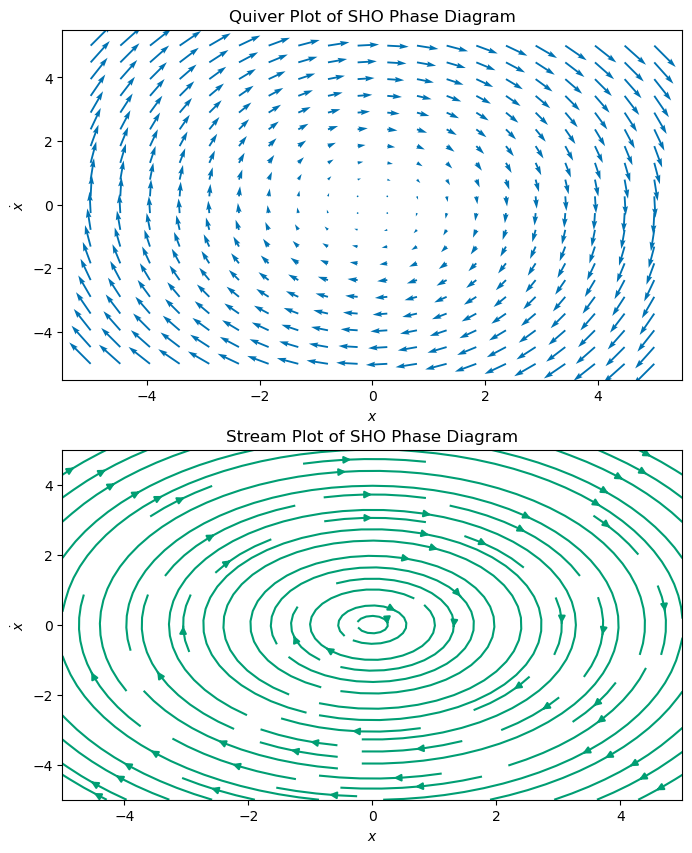

In [14]:
fig, axs = plt.subplots(2, 1, figsize=(8, 10))  # Two rows, one column
    
# Quiver plot on the first subplot
axs[0].quiver(X, V, dX, dV, color='C0')
axs[0].set_title('Quiver Plot of SHO Phase Diagram')
axs[0].set_xlabel(r'$x$')
axs[0].set_ylabel(r'$\dot{x}$')

# Stream plot on the second subplot
axs[1].streamplot(X, V, dX, dV, color='C1')
axs[1].set_title('Stream Plot of SHO Phase Diagram')
axs[1].set_xlabel(r'$x$')
axs[1].set_ylabel(r'$\dot{x}$');

* 4a (2pt) Explain how the code works to produce the phase diagram. The key part is explaining what the function `SHO` does and how that relates to the `quiver` and `streamplot` calls. What does `np.meshgrid` do and why is it used?

**The function SHO defines the differential equations of the simple harmonic system v = dx/dt and dv/dt = -x. The spring constant is set to 1. The quiver command plots at the x, v point the respective gradient at that specific point with the direction showing the change in x,v. In this case, dx/dt = v and dv/dt =-x. The streamplot command creates lines that follows the direction of the gradients to show the flow of the vector field. The np.meshgrid creates a rectangular grid of points based on the input arrays x, v. This is used so the gradient can be calculated for every point in the grid.**

We have discussed the physical pendulum in class where the potential energy is given by:

$$U(\theta)=mgl(1-\cos\theta)$$

* 4b (4pt) Modify the code to produce the phase diagram for the physical pendulum. You can choose mass and length. Make sure to explore the diagram outside of the small angle approximation. What new features do you observe in the phase diagram? What motion are they associated with?

$$
F(\theta) = -\frac{dU(\theta)}{d\theta} = -mg\sin(\theta)
$$

$$
mL\frac{d\theta}{dt} = -mg\sin(\theta)
$$

$$
\frac{d\theta}{dt} = -\frac{g}{L}\sin(\theta)
$$

In [61]:
def SHO_pend(theta,V):
    g = 9.8
    dtheta = V     #The ODEs of the physical pendulum are: v = dtheta/dt , dv/dt = -(g/L) sin(theta) where L is length
    dV = -(g/3) * np.sin(theta)   #Chose length of pendulum to be 1.5m
    
    return dX, dV

def generate_phase_space_pend(x_lim, v_lim, grid_size):

    theta = np.linspace(x_lim[0], x_lim[1], grid_size)
    v = np.linspace(v_lim[0], v_lim[1], grid_size)
    
    theta, V = np.meshgrid(theta, v)
    
    dtheta, dV = SHO_pend(X, V)
    
    return theta, V, dtheta, dV

# Generate phase space
x_lim = (-4*np.pi, 4*np.pi)
v_lim = (-20, 20)
grid_size = 20
theta, V1, dtheta, dV1 = generate_phase_space_pend(x_lim, v_lim, grid_size)

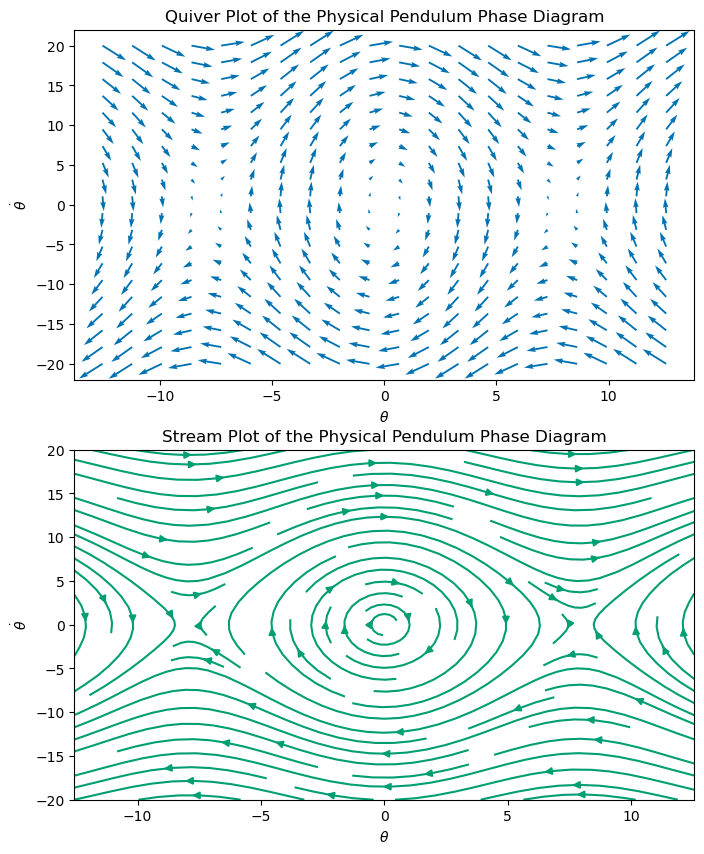

In [64]:
fig, axs = plt.subplots(2, 1, figsize=(8, 10))  # Two rows, one column
    
# Quiver plot on the first subplot
axs[0].quiver(theta, V1, dtheta, dV1, color='C0')
axs[0].set_title('Quiver Plot of the Physical Pendulum Phase Diagram')
axs[0].set_xlabel(r'$\theta$')
axs[0].set_ylabel(r'$\dot{\theta}$')

# Stream plot on the second subplot
axs[1].streamplot(theta, V1, dtheta, dV1, color='C1')
axs[1].set_title('Stream Plot of the Physical Pendulum Phase Diagram')
axs[1].set_xlabel(r'$\theta$')
axs[1].set_ylabel(r'$\dot{\theta}$');

**The physical pendulum's phase diagram has multiple critical points or points where the force is zero (or the derivative of the potential energy is zero). The plot shows a stable point at (0,0) where the flow of gradients of x,v revolve around. However unlike the SHO system, there are two unstable points on either end of the stable (0,0) point where the system is flowing away from that point.**



Now we have a code that we can use to plot the phase diagram of any 1D system. We will use it to explore the damped harmonic oscillator and the damped physical pendulum. Here we write the equations of motion as the system is still 1-D, but the forces are not derived from a potential.

The damped harmonic oscillator has the equation of motion:
$$\ddot{x}=-\frac{k}{m}x-\frac{b}{m}\dot{x}$$

* 4c (5pt) Modify the code to produce the phase diagram for the damped harmonic oscillator. You can choose $k/m$ and $b/m$, but might want to explore the values. What features do you observe in the phase diagram? What motion are they associated with?

In [149]:
def SHO_damped(X,V):
    dX = V
    dV = -4*X - 2*V   #k/m has been chosen to be 4. b/m is chosen to be 2

    return dX, dV

def generate_phase_space_damped(x_lim, v_lim, grid_size):

    x = np.linspace(x_lim[0], x_lim[1], grid_size)
    v = np.linspace(v_lim[0], v_lim[1], grid_size)
    
    X, V = np.meshgrid(x, v)
    
    dX, dV = SHO_damped(X, V)
    
    return X, V, dX, dV

# Generate phase space
x_lim = (-5, 5) 
v_lim = (-5, 5)
grid_size = 20
X_d, V_d, dX_d, dV_d = generate_phase_space_damped(x_lim, v_lim, grid_size)

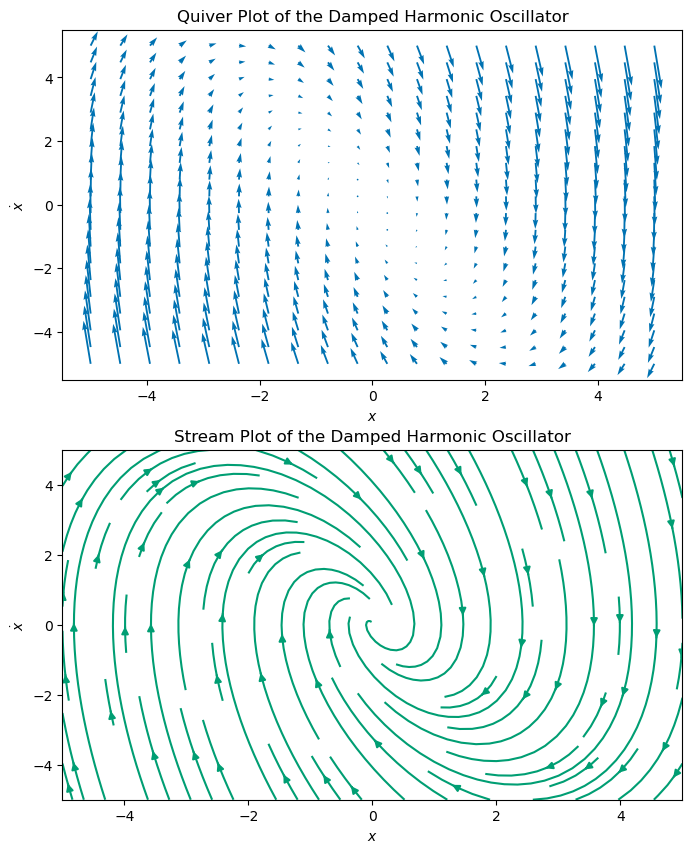

In [150]:
fig, axs = plt.subplots(2, 1, figsize=(8, 10))  # Two rows, one column
    
# Quiver plot on the first subplot
axs[0].quiver(X_d, V_d, dX_d, dV_d, color='C0')
axs[0].set_title('Quiver Plot of the Damped Harmonic Oscillator')
axs[0].set_xlabel(r'$x$')
axs[0].set_ylabel(r'$\dot{x}$')

# Stream plot on the second subplot
axs[1].streamplot(X_d, V_d, dX_d, dV_d, color='C1')
axs[1].set_title('Stream Plot of the Damped Harmonic Oscillator')
axs[1].set_xlabel(r'$x$')
axs[1].set_ylabel(r'$\dot{x}$');

**The phase diagram of the damped harmonic oscillator shows the same stable point (0,0) like the SHO plot. However, we can notice spirals in the system's flow. This means the system oscillates until it reaches the point (0,0) due to the energy loss of the damping. This is unlike the SHO phase diagram where the oscillation occurs around x=0 but never reaches it.**

**When the damping term b/m is much higher than k/m, the system rapidy approaches x=0.**

The damped physical pendulum has the equation of motion:
$$\ddot{\theta}=-\frac{g}{l}\sin\theta-\frac{b}{ml}\dot{\theta}$$

* 4d (5pt) Modify the code again to produce the phase diagram for the damped physical pendulum. You can choose $b/ml$, but might want to explore the values. How does this motion compare to the motion of the damped harmonic oscillator? 

In [156]:
def SHO_damped_pend(theta,V):
    g = 9.8
    dtheta = V     
    dV = -(g/1) * np.sin(theta) - 1*V  #The length l is 1 and b/ml was chosen to be 1
    
    return dX, dV

def generate_phase_space_damped_pend(x_lim, v_lim, grid_size):

    theta = np.linspace(x_lim[0], x_lim[1], grid_size)
    v = np.linspace(v_lim[0], v_lim[1], grid_size)
    
    theta, V = np.meshgrid(theta, v)
    
    dtheta, dV = SHO_damped_pend(X, V)
    
    return theta, V, dtheta, dV

# Generate phase space
x_lim = (-4*np.pi, 4*np.pi)
v_lim = (-20, 20)
grid_size = 20
theta_dp, V_dp, dtheta_dp, dV_dp = generate_phase_space_damped_pend(x_lim, v_lim, grid_size)

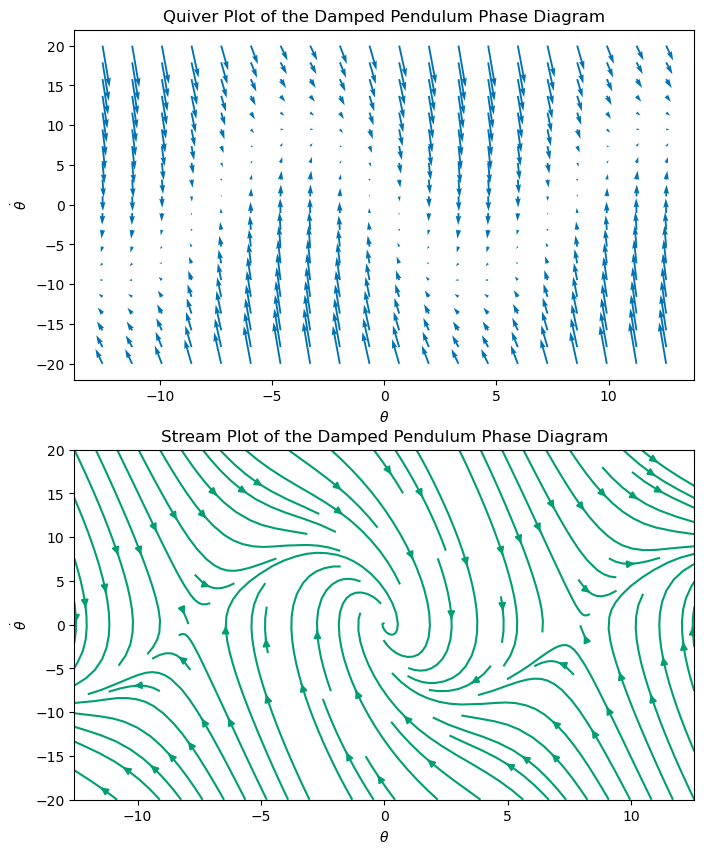

In [157]:
fig, axs = plt.subplots(2, 1, figsize=(8, 10))  # Two rows, one column
    
# Quiver plot on the first subplot
axs[0].quiver(theta_dp, V_dp, dtheta_dp, dV_dp, color='C0')
axs[0].set_title('Quiver Plot of the Damped Pendulum Phase Diagram')
axs[0].set_xlabel(r'$\theta$')
axs[0].set_ylabel(r'$\dot{\theta}$')

# Stream plot on the second subplot
axs[1].streamplot(theta_dp, V_dp, dtheta_dp, dV_dp, color='C1')
axs[1].set_title('Stream Plot of the Damped Pendulum Phase Diagram')
axs[1].set_xlabel(r'$\theta$')
axs[1].set_ylabel(r'$\dot{\theta}$')

plt.show()

**The phase diagram of a damped pendulum shows a stable point at (0,0) and the unstable points similar to the physical pendulum phase diagram. The system's flow is away from the unstable points and towards the stable point x=0. We  observe spirals where the damped oscillations with some initial x,v always lead to the point x=0 similar to the damped oscillator phase diagram. The system also spirals rapidly into x=0 when the damping term b/ml is much greater than g/l.**

* 4e (4pt) Return to the simple harmonic oscillator. Show using conservation of energy the phase diagram is a series of ellipses in $(x,v)$ space. Plot these ellipses on top of a phase diagram for the simple harmonic oscillator to illustrate how the phase diagram explains the total energy of the system.